# MediBot — Milestone 2, Part 1: Exploratory Data Analysis

## Why EDA matters (and what we're looking for)

Before we embed anything into a vector index or wire up any agents, we need to **understand the data**. EDA (Exploratory Data Analysis) is the phase where you play detective: you inspect shapes, distributions, data quality, and relationships before you commit to an architecture.

For MediBot specifically, EDA answers questions that directly shape the RAG pipeline:

| Question | Why it matters for the pipeline |
|---|---|
| How many diseases and symptoms? | Determines index size and embedding cost |
| Is each disease row unique, or duplicated? | Tells us whether to deduplicate before indexing |
| Are symptom strings clean? | Whitespace/case bugs are the #1 cause of retrieval misses |
| How specific is each symptom? (how many diseases share it?) | Drives whether we retrieve by single symptoms or clusters |
| What's the severity distribution? | Feeds the severity agent's thresholds |
| Do all diseases have descriptions/precautions? | Coverage gaps = silent failures in production |

**Teaching-as-we-go concepts you'll see:** pandas DataFrames, `value_counts`, `groupby`, tidy/long-format data, co-occurrence analysis, and why normalization is non-negotiable.


## 1. Setup and load

**Concept — pandas DataFrame:** think of a `DataFrame` as a SQL table or a spreadsheet, but queryable with Python. Every column is a named `Series` (a typed array). 90% of real-world data work in Python flows through these two objects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

DATA = Path("../data/raw")

df_map = pd.read_csv(DATA / "dataset.csv")
df_sev = pd.read_csv(DATA / "Symptom-severity.csv")
df_desc = pd.read_csv(DATA / "symptom_Description.csv")
df_prec = pd.read_csv(DATA / "symptom_precaution.csv")

print(f"dataset.csv            : {df_map.shape}  (disease -> 17 symptom cols)")
print(f"Symptom-severity.csv   : {df_sev.shape}  (symptom, weight)")
print(f"symptom_Description.csv: {df_desc.shape}  (disease, description)")
print(f"symptom_precaution.csv : {df_prec.shape}  (disease, 4 precautions)")


dataset.csv            : (4920, 18)  (disease -> 17 symptom cols)
Symptom-severity.csv   : (133, 2)  (symptom, weight)
symptom_Description.csv: (41, 2)  (disease, description)
symptom_precaution.csv : (41, 5)  (disease, 4 precautions)


In [2]:
df_map.head(3)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data quality check

Real-world data is almost never clean. Before we use any of these columns downstream, we need to look for:
- **Missing values** (NaN cells)
- **Whitespace** (`' skin_rash'` vs `'skin_rash'` — these look identical but match differently)
- **Case inconsistencies**
- **Duplicate rows**

**Concept — why this matters for RAG:** if we embed `' skin_rash'` with a leading space and the severity CSV has `'skin_rash'`, our symptom→severity lookups silently fail. One of the most common production bugs in LLM apps is string-key mismatch on pre-processed data.


In [3]:
# Missing values per CSV
print("Missing values per column (dataset.csv):")
print(df_map.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows in dataset.csv:", df_map.duplicated().sum())


Missing values per column (dataset.csv):
Symptom_17    4848
Symptom_16    4728
Symptom_15    4680
Symptom_14    4614
Symptom_13    4416
Symptom_12    4176
Symptom_11    3726
Symptom_10    3408
Symptom_9     3228
Symptom_8     2976
dtype: int64

Duplicate rows in dataset.csv: 4616


In [4]:
# Hunt for whitespace issues by comparing raw string to its stripped version.
symptom_cols = [c for c in df_map.columns if c.startswith("Symptom_")]
raw = df_map[symptom_cols].stack()  # all non-null symptom cells, flattened
stripped_mismatches = (raw != raw.str.strip()).sum()
print(f"Cells with leading/trailing whitespace: {stripped_mismatches} / {len(raw)}")

# Example
sample = raw[raw != raw.str.strip()].head(5)
print("\nExamples:")
for v in sample:
    print(f"  repr={v!r}")


Cells with leading/trailing whitespace: 82962 / 83640

Examples:
  repr=' skin_rash'
  repr=' nodal_skin_eruptions'
  repr=' dischromic _patches'
  repr=nan
  repr=nan


## 3. Normalize + reshape to long (tidy) format

**Concept — tidy (long) data:** when every row is *one observation* of *one variable*, pandas and any downstream ML tool becomes dramatically easier to use. Hadley Wickham's 2014 paper formalized this, but it's now the default shape for any data science work.

Our `dataset.csv` is **wide**: one disease row, with 17 symptom columns (most NaN). We want **long**: one row per (disease, symptom) pair. This is what `melt` does.


In [5]:
def normalize_symptom(s):
    if pd.isna(s):
        return None
    return s.strip().lower().replace("  ", " ")

# Normalize disease column too
df_map["Disease"] = df_map["Disease"].str.strip()

# Wide -> long (melt)
long = df_map.melt(
    id_vars="Disease",
    value_vars=symptom_cols,
    var_name="slot",
    value_name="symptom",
)
long["symptom"] = long["symptom"].map(normalize_symptom)
long = long.dropna(subset=["symptom"]).drop(columns="slot").drop_duplicates()

print("Long-format shape:", long.shape)
long.head()


Long-format shape: (321, 2)


,Disease,symptom
0,Fungal infection,itching
1,Fungal infection,skin_rash
10,Allergy,continuous_sneezing
11,Allergy,shivering
20,GERD,stomach_pain


## 4. Disease distribution — is the data balanced?

**Concept — class balance:** if one disease dominates 80% of rows, any naive similarity search will bias toward it. We check this early because it affects both retrieval tuning and evaluation design.


Distinct diseases: 41
Row count per disease — min 120, max 120, median 120


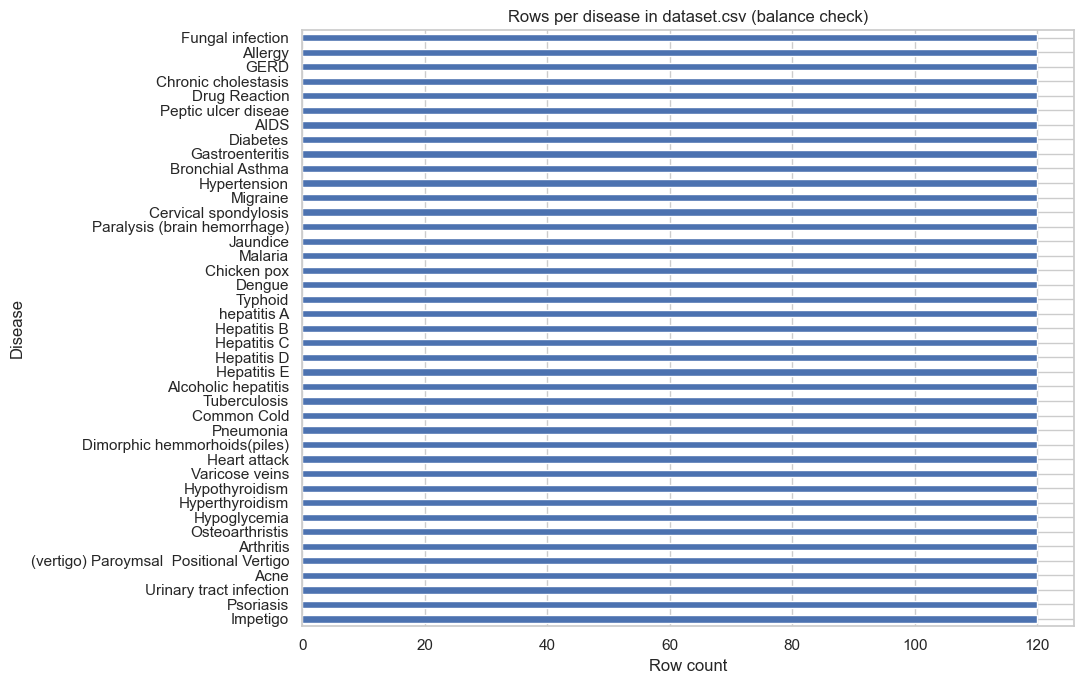

In [6]:
disease_counts = df_map["Disease"].value_counts()
print(f"Distinct diseases: {disease_counts.shape[0]}")
print(f"Row count per disease — min {disease_counts.min()}, max {disease_counts.max()}, median {int(disease_counts.median())}")

fig, ax = plt.subplots(figsize=(11, 7))
disease_counts.plot.barh(ax=ax)
ax.set_xlabel("Row count")
ax.set_title("Rows per disease in dataset.csv (balance check)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Symptom severity — the urgency signal

The severity agent needs a threshold model: *above what combined weight do we say "see a doctor now"?*  Let's see the distribution.


count    133.000000
mean       4.225564
std        1.323543
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        7.000000
Name: weight, dtype: float64


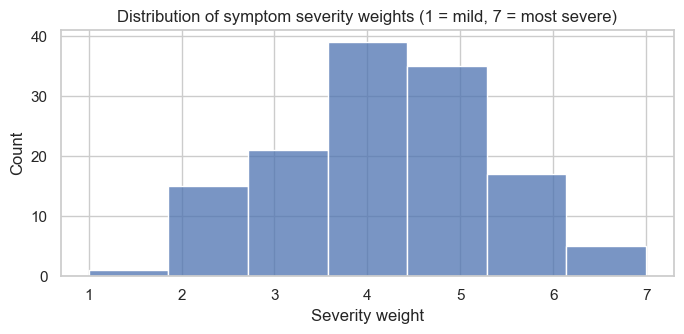

In [7]:
df_sev.columns = [c.strip() for c in df_sev.columns]
df_sev["Symptom"] = df_sev["Symptom"].map(normalize_symptom)

print(df_sev["weight"].describe())

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(df_sev["weight"], bins=df_sev["weight"].nunique(), ax=ax)
ax.set_title("Distribution of symptom severity weights (1 = mild, 7 = most severe)")
ax.set_xlabel("Severity weight")
plt.tight_layout(); plt.show()


## 6. Symptom specificity — how informative is each symptom?

A symptom that appears in 30 diseases (e.g. `fatigue`) is a weak retrieval signal. A symptom that appears in 1 (e.g. `bloody_stool`) is very strong. This is analogous to **IDF (inverse document frequency)** in classical IR.

**Concept — IDF intuition:** rare terms are more discriminative. Modern embedding models learn this implicitly, but understanding the data's inherent specificity helps you pick a reranker or set thresholds.


Distinct symptoms in dataset.csv: 131
Most shared (lowest specificity) top 10:
symptom
fatigue              17
vomiting             17
high_fever           12
nausea               10
loss_of_appetite     10
headache             10
abdominal_pain        9
yellowish_skin        8
yellowing_of_eyes     7
skin_rash             7
Name: Disease, dtype: int64

Most specific (mapped to 1 disease only): 80 symptoms


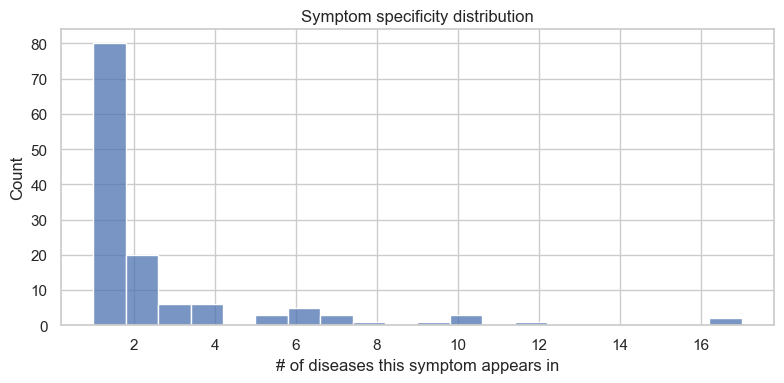

In [8]:
sym_to_disease_count = long.groupby("symptom")["Disease"].nunique().sort_values(ascending=False)

print(f"Distinct symptoms in dataset.csv: {sym_to_disease_count.shape[0]}")
print(f"Most shared (lowest specificity) top 10:")
print(sym_to_disease_count.head(10))
print(f"\nMost specific (mapped to 1 disease only): {(sym_to_disease_count == 1).sum()} symptoms")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sym_to_disease_count, bins=20, ax=ax)
ax.set_xlabel("# of diseases this symptom appears in")
ax.set_title("Symptom specificity distribution")
plt.tight_layout(); plt.show()


## 7. Coverage check — do all diseases have descriptions and precautions?

If the RAG pipeline asks for a description of Disease X and there's no row in `symptom_Description.csv`, the user gets a silent gap. This is a **coverage bug** — easy to miss in testing, painful in production.


In [9]:
df_desc["Disease"] = df_desc["Disease"].str.strip()
df_prec["Disease"] = df_prec["Disease"].str.strip()

diseases_in_map = set(df_map["Disease"].unique())
diseases_desc = set(df_desc["Disease"].unique())
diseases_prec = set(df_prec["Disease"].unique())

print(f"Diseases in dataset.csv     : {len(diseases_in_map)}")
print(f"Diseases with description   : {len(diseases_desc)}")
print(f"Diseases with precautions   : {len(diseases_prec)}")
print(f"\nIn map but missing description: {sorted(diseases_in_map - diseases_desc)}")
print(f"In map but missing precaution : {sorted(diseases_in_map - diseases_prec)}")


Diseases in dataset.csv     : 41
Diseases with description   : 41
Diseases with precautions   : 41

In map but missing description: ['Dimorphic hemmorhoids(piles)']
In map but missing precaution : []


## 8. Co-occurrence of symptoms

**Concept — co-occurrence matrix:** for each pair of symptoms (A, B), how often do they appear in the same disease? This reveals symptom clusters. It's also the bedrock of classical word-embeddings (GloVe / SVD on co-occurrence matrices), and it's a great sanity check against your embedding model later — the pairs that co-occur most in data should also be most similar in embedding space.


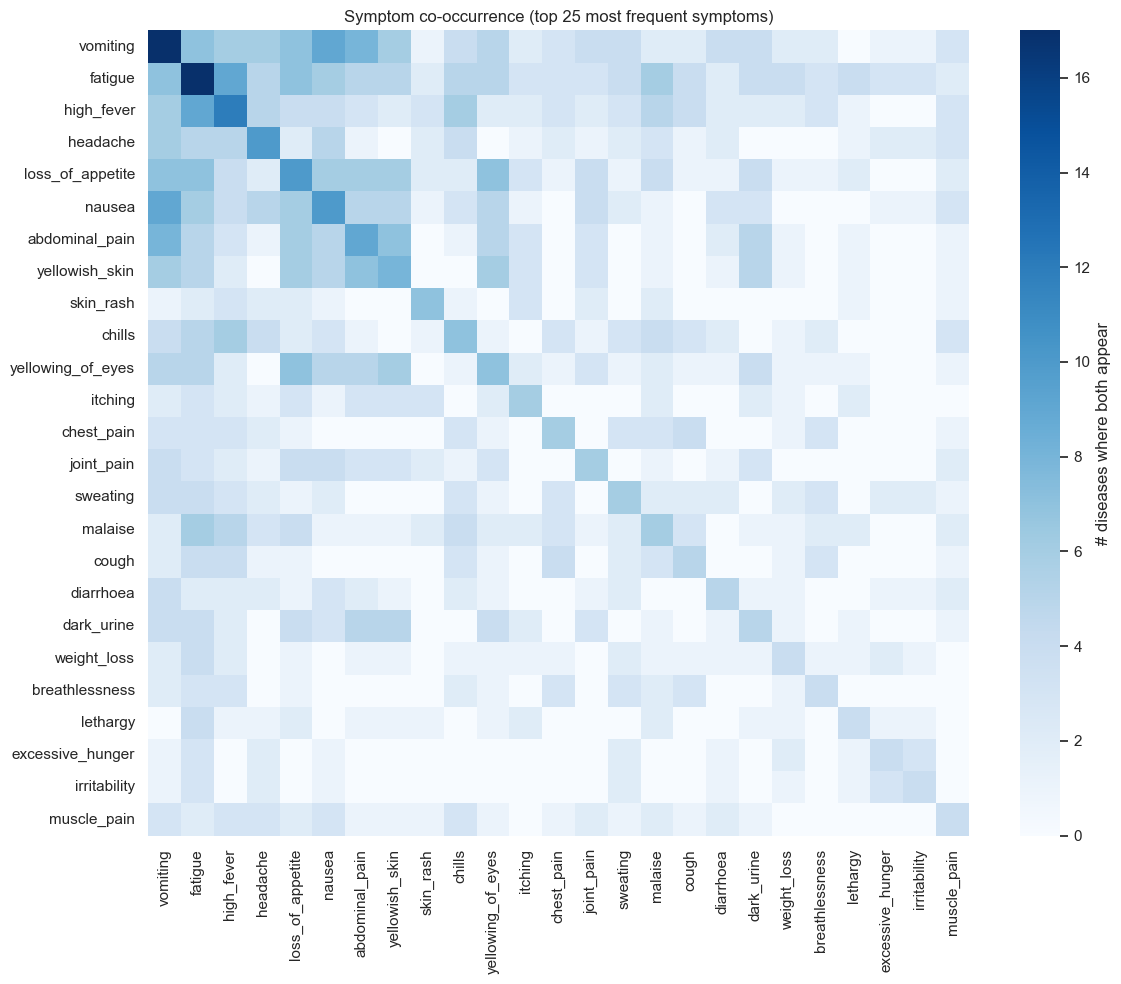

In [10]:
# Build disease -> set of symptoms
disease_symptoms = long.groupby("Disease")["symptom"].apply(set)

# Top 25 symptoms by frequency, so the heatmap is readable
top_symptoms = long["symptom"].value_counts().head(25).index.tolist()

# Co-occurrence counts
co = pd.DataFrame(0, index=top_symptoms, columns=top_symptoms)
for syms in disease_symptoms:
    present = [s for s in syms if s in top_symptoms]
    for a in present:
        for b in present:
            co.loc[a, b] += 1

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(co, cmap="Blues", ax=ax, cbar_kws={"label": "# diseases where both appear"})
ax.set_title("Symptom co-occurrence (top 25 most frequent symptoms)")
plt.tight_layout(); plt.show()


## 9. Takeaways for the RAG design

From the analysis above, design decisions for Part 2 (FAISS):

1. **Normalize all symptoms** (`strip().lower()`) before indexing *and* before querying. Non-negotiable.
2. **Index granularity:** embed one text blob per **disease** (disease name + all its symptoms + description), not per symptom. This gives retrieval the richest context per vector.
3. **Dedup:** `dataset.csv` has ~120 rows per disease — these are the same disease with different symptom orderings. Collapse them before indexing.
4. **Cover the coverage gaps:** make sure every disease in the map is joinable to a description and precautions before indexing. Fail loudly if not.
5. **Use severity weights downstream, not during retrieval:** retrieval finds candidate diseases; severity scoring is a separate post-step inside the severity agent.
6. **Top-k choice:** with ~41 diseases, `k=5` for retrieval is plenty. For >1000-doc corpora you'd tune this.

Next: Part 2 — build the FAISS index.
